# **Combined dataset (FingerVein + PPG)**
The proposal defines a **third, combined dataset** built by *pairing* a FingerVein sample with a PPG sample that share the **same sex and the same age** ("accoppiando campioni FingerVein e PPG con lo stesso sesso e la stessa età"). This combined set feeds **Model C**, the two-branch early-fusion network.

The two modalities have **no common subjects**: they are different people from different acquisition campaigns. The only thing we can align on is the **demographics**: each notebook already produces a per-subject table with `Age` + `Gender`, which is exactly the pairing key.

> **Leakage matters.** Per the proposal, the train/val/test split is done **per subject, within each modality, *before* pairing**. We pair only *inside* a given split, so a subject (FV or PPG) never leaks across splits.

## **Why combine the two datasets? (the point of this notebook)**

Testing whether the combination is useful is literally the heart of this project. Here is the
idea, in plain words.

### The core idea: two views beat one

Imagine you want to guess someone's age, but you can't see their face. Instead you ask two people:

- **Expert A** only gets to see a **finger-vein image** (the pattern of veins).
- **Expert B** only gets to hear the **heartbeat / pulse** (the PPG signal).

Both change with age: vein texture and vessel structure shift as we get older, and so does the
*shape* of the pulse wave. But they change for **different biological reasons**, so each expert is
noticing **different clues**.

When two experts look at *different evidence*, combining their guesses is often **more accurate**
than trusting either one alone. That is the whole bet behind a combined (multimodal) dataset:

1. **Complementary information**: where the vein image is unclear for one person, the pulse might
   still be informative, and vice-versa. Together they cover each other's blind spots.
2. **Robustness**: if one signal is noisy (a blurry image, a shaky pulse recording), the model
   can lean on the other instead of being stuck.

### Why this is *our project*, specifically

The proposal does not just *assume* fusion helps, it asks us to **prove or disprove it** by
comparing four things on the same test people:

- Model **A** (vein only): Expert A alone
- Model **B** (pulse only): Expert B alone
- **Score fusion**: let A and B each guess, then blend the two guesses (e.g. average)
- Model **C** (joint two-branch network): one model that looks at *both* at once

If the combined approaches (fusion / C) get a **lower error** (MAE, RMSE) than A or B alone, we
have shown fusion is worth it. If they *don't*, that is also a real, reportable result. **The
usefulness is the question we are measuring**, not something we take on faith.

### The honest caveat for *our* data (important)

In an *ideal* multimodal dataset, the vein image **and** the pulse come from the **same person**,
then fusion is very powerful, because the two views describe one individual.

In our case (see the pairing below), the image and the pulse come from **different people**,
matched only by age and sex. So the model cannot learn "*this specific person's* veins go with
*this specific person's* pulse." It can only learn the weaker, general pattern: "*a typical
27-year-old's* veins + *a typical 27-year-old's* pulse → 27."

That means:
- Fusion **can** still help a bit (more varied examples, two sources of the age signal), **but**
- the benefit is **limited** compared to truly paired data, and **finding that out is itself a
  valid result** to report, especially since we use provisional public data, not the official
  paired datasets.

> **In one sentence:** a combined dataset is useful when the two modalities carry different clues
> about age, so blending them gives a more accurate and more robust estimate, and our job is to
> measure how much that is actually true here, honestly accounting for the fact that our two
> modalities come from different people.

# **Preliminary operations**
The lab notebooks fetch their data on the fly (e.g. `!wget ...` in *DL_01: Regression*).
This project instead uses **non-public, provisional archives** that we keep **locally** and
**out of version control** (`*.zip` and `proj_files/` are git-ignored). There is therefore
nothing to download here.

Before running the notebook, place the dataset archives under `proj_files/` at the
repository root:

```
proj_files/
├── MMCBNU_6000.zip                                            ← FingerVein
└── brno-university-of-technology-...-but-ppg-2.0.0.zip        ← PPG
```

We read the data **directly from the `.zip`** (the FingerVein `.bmp` images and the PPG WFDB records), so the archives do not need to be
extracted.


# **Useful module imports**
This notebook is **self-contained**: it re-imports the loaders of both modalities so it can
run on its own. We import every module first, then fix a documented random seed for the
per-subject split and the pairing done later.


In [10]:
import io
import os
import zipfile
import random
import tempfile
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from pypdf import PdfReader
import wfdb

# Reproducibility: one documented seed for the per-subject split and pairing
# (see AGENTS.md, "Scientific constraints").
SEED = 0
random.seed(SEED)
np.random.seed(SEED)

# **Datasets**
The combined dataset is built from the two **provisional public** archives explored in
notebooks 01 and 02:

| Modality | Archive | Demographics source |
|---|---|---|
| FingerVein | `MMCBNU_6000.zip` | `age`, `gender` parsed from the bundled description **PDF** |
| PPG | `...but-ppg-2.0.0.zip` | `Age [years]`, `Gender` from `subject-info.csv` |

The two modalities share **no subjects** (different people, different acquisition campaigns);
the only common key is the **(age, gender)** demographics, which is exactly what we pair on (`proposta-rivista.md`, §2).

> ⚠️ The FingerVein age/gender come from a PDF Information table, not the dataset's signal
> files: see the provenance note in notebook 01. Treat every combined-dataset result as
> **exploratory** until the official non-public data are available.

The cell below locates both archives under `proj_files/`.


In [11]:
PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == 'notebooks':
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_DIR = PROJECT_ROOT / 'proj_files'
FV_ZIP = DATA_DIR / 'MMCBNU_6000.zip'
PPG_ZIP = DATA_DIR / 'brno-university-of-technology-smartphone-ppg-database-but-ppg-2.0.0.zip'

assert FV_ZIP.exists(), f'FingerVein archive not found: {FV_ZIP} (see "Preliminary operations")'
assert PPG_ZIP.exists(), f'PPG archive not found: {PPG_ZIP} (see "Preliminary operations")'
print('Repository root :', PROJECT_ROOT)
print('FingerVein zip  :', FV_ZIP.name)
print('PPG zip         :', PPG_ZIP.name)

Repository root : /Users/muni/Documents/uni/DL/PPG_FingerVein_age_detection
FingerVein zip  : MMCBNU_6000.zip
PPG zip         : brno-university-of-technology-smartphone-ppg-database-but-ppg-2.0.0.zip


# **The two label tables (the pairing key)**
We load the per-subject demographics from each modality and reduce them to a **common schema** `uid, age, gender`:

- **FingerVein**: parsed from the *Information table* in `Description of MMCBNU_6000.pdf` (1 row per subject `001..100`);
- **PPG**: from `subject-info.csv` (1 row per record).

Gender is already encoded as `M`/`F` in **both** datasets, so no remapping is needed.

In [12]:
def load_fv_info(zip_path):
    """Per-subject (age, gender) for FingerVein, from the description PDF inside the archive."""
    with zipfile.ZipFile(zip_path) as z:
        pdf_name = next(n for n in z.namelist() if n.lower().endswith('.pdf'))
        reader = PdfReader(io.BytesIO(z.read(pdf_name)))
    text = '\n'.join((page.extract_text() or '') for page in reader.pages)
    rows = []
    for line in text.splitlines():
        toks = line.split()
        if len(toks) >= 4 and toks[0].isdigit() and toks[1].isdigit():
            gi = next((i for i, t in enumerate(toks[2:], 2) if t in ('M', 'F')), None)
            if gi is None:
                continue
            rows.append({'uid': f'{int(toks[0]):03d}', 'age': int(toks[1]), 'gender': toks[gi]})
    return pd.DataFrame(rows)


def load_ppg_info(zip_path):
    """Per-record (age, gender) for PPG. The 6-digit ID is <subject(3)><recording(3)>, so we
    add `subj` = the real person id: BUT PPG has only 50 subjects, not 3888 records."""
    with zipfile.ZipFile(zip_path) as z:
        csv_name = next(n for n in z.namelist() if n.endswith('subject-info.csv'))
        df = pd.read_csv(io.BytesIO(z.read(csv_name)))
    df = df.assign(age=pd.to_numeric(df['Age [years]'], errors='coerce'))
    df = df.rename(columns={'ID': 'uid', 'Gender': 'gender'})
    df = df[['uid', 'age', 'gender']].dropna(subset=['age'])
    df['uid'] = df['uid'].astype(str)
    df['subj'] = df['uid'].str[:3]            # <-- the real person (50 distinct)
    df['age'] = df['age'].astype(int)
    return df.reset_index(drop=True)


def list_fv_images(zip_path):
    """One row per FingerVein ROI image (the model input); uid = the subject folder."""
    with zipfile.ZipFile(zip_path) as z:
        names = [n for n in z.namelist() if n.lower().endswith('.bmp') and '/ROIs/' in n]
    img = pd.DataFrame({'img': sorted(names)})
    img['uid'] = img['img'].str.split('/').str[-3]
    return img


fv = load_fv_info(FV_ZIP)
ppg = load_ppg_info(PPG_ZIP)
fv_img = list_fv_images(FV_ZIP).merge(fv, on='uid')      # attach age/gender to each image

print(f'FingerVein : {fv.uid.nunique()} subjects, {len(fv_img)} ROI images'
      f' | gender {fv.gender.value_counts().to_dict()} | age {fv.age.min()}-{fv.age.max()}')
print(f'PPG        : {ppg.subj.nunique()} subjects, {ppg.uid.nunique()} segments'
      f' | gender {ppg.drop_duplicates("subj").gender.value_counts().to_dict()} | age {ppg.age.min()}-{ppg.age.max()}')

FingerVein : 100 subjects, 6000 ROI images | gender {'M': 83, 'F': 17} | age 16-72
PPG        : 50 subjects, 3888 segments | gender {'F': 25, 'M': 25} | age 19-76


# **How big is this, really?**
"Too small" has to be measured at the right level. There are **three** very different counts,
and they pull in opposite directions:

- **Identities**: distinct people. This is the *hard ceiling* on what a model can learn, and it
  is small: **100** FV + **50** PPG subjects. No pairing or augmentation can raise it.
- **Samples**: real measurements: **6000** FV ROI images and **3888** PPG segments. Plenty.
- **Demographic cells**: `(gender, age)` combinations the two sets share; this caps the
  *diversity* of any pairing.

So the combined set is rich in samples but poor in identities/diversity. The honest consequence:
combined results are **exploratory**, and we keep validation/test **subject-disjoint** so the
score is not inflated by reusing the same people.

In [13]:
fv_cells = set(zip(fv.gender, fv.age))
ppg_cells = set(zip(ppg.gender, ppg.age))
print('shared (gender, exact age) cells :', len(fv_cells & ppg_cells))
for tol in (0, 1, 2, 5):
    cov = sum(((ppg.gender == fr.gender) & (ppg.age.sub(fr.age).abs() <= tol)).any()
              for fr in fv.itertuples(index=False))
    print(f'  FV subjects with >=1 PPG match (age_tol={tol}) : {cov}/{len(fv)}')

shared (gender, exact age) cells : 15
  FV subjects with >=1 PPG match (age_tol=0) : 61/100
  FV subjects with >=1 PPG match (age_tol=1) : 83/100
  FV subjects with >=1 PPG match (age_tol=2) : 94/100
  FV subjects with >=1 PPG match (age_tol=5) : 100/100


# **Step 1: per-subject split (before pairing)**
Each modality is split **independently and by subject**, *before* any pairing, so no person's
samples cross train/val/test (the proposal's anti-leakage rule).

- **FingerVein:** the split key is the subject `uid` (one folder per person).
- **PPG:** the key is **`subj`** (the 3-digit person id), **not** the record `uid`. Splitting on
  the record id would scatter one person's ~78 recordings across all three splits, that is
  leakage, and it was the bug in the first version of this notebook.

In [14]:
def split_by_subject(df, key='uid', frac=(0.7, 0.15, 0.15), seed=0):
    """Assign each distinct subject (column `key`) to train/val/test - no subject overlap."""
    subs = df[key].drop_duplicates().sample(frac=1.0, random_state=seed).tolist()
    n = len(subs)
    a, b = int(frac[0] * n), int((frac[0] + frac[1]) * n)
    tag = {s: ('train' if i < a else 'val' if i < b else 'test') for i, s in enumerate(subs)}
    return df.assign(split=df[key].map(tag))


fv = split_by_subject(fv, key='uid', seed=SEED)
ppg = split_by_subject(ppg, key='subj', seed=SEED)
fv_img['split'] = fv_img['uid'].map(fv.set_index('uid')['split'])     # carry split onto each image

print('FV  subjects/split :', fv.drop_duplicates('uid').split.value_counts().to_dict())
print('PPG subjects/split :', ppg.drop_duplicates('subj').split.value_counts().to_dict())

FV  subjects/split : {'train': 70, 'test': 15, 'val': 15}
PPG subjects/split : {'train': 35, 'test': 8, 'val': 7}


# **Step 2: many-to-many pairing within each split**
One PPG record per FV subject gave only ~100 fused rows, too few to train Model C. Instead we
pair at the **sample** level: within a split, each **FV image** is matched to PPG **segments** of
the same gender and an age within `age_tol`, and we draw `ppg_per_image` of them. Every pair uses
a **real** image and a **real** segment, this is *not* synthetic data; it just reuses the many
samples each subject already provides.

Two guards keep it honest:
- **`cap_per_cell`** limits pairs per `(gender, age)` cell, so the dense 25–30 cluster cannot
  dominate the set;
- we expand **train** generously but keep **val/test** small (one segment per image). The
  per-subject split already guarantees no identity leaks across the three sets.

In [7]:
def make_pairs(fv_img, ppg, split, age_tol=1, ppg_per_image=1, cap_per_cell=None, seed=0):
    """Many-to-many (FV image x PPG segment) pairs inside one split.
    Same gender, |age difference| <= age_tol, same split (=> no leakage)."""
    rng = np.random.default_rng(seed)
    f = fv_img[fv_img.split == split]
    p = ppg[ppg.split == split]
    rows = []
    for fr in f.itertuples(index=False):
        cand = p[(p.gender == fr.gender) & (p.age.sub(fr.age).abs() <= age_tol)]
        if cand.empty:
            continue
        k = min(ppg_per_image, len(cand))
        pick = cand.iloc[rng.choice(len(cand), size=k, replace=False)]
        for pr in pick.itertuples(index=False):
            rows.append({'fv_uid': fr.uid, 'fv_img': fr.img,
                         'ppg_uid': pr.uid, 'ppg_subj': pr.subj,
                         'gender': fr.gender, 'age': fr.age, 'ppg_age': int(pr.age),
                         'split': split})
    out = pd.DataFrame(rows)
    if cap_per_cell and not out.empty:
        out = (out.sample(frac=1.0, random_state=seed)            # shuffle, then keep a capped
                  .groupby(['gender', 'age'], group_keys=False)   # number of pairs per cell
                  .head(cap_per_cell))
    return out.reset_index(drop=True)


AGE_TOL = 1
combined = pd.concat([
    make_pairs(fv_img, ppg, 'train', age_tol=AGE_TOL, ppg_per_image=3, cap_per_cell=300, seed=SEED),
    make_pairs(fv_img, ppg, 'val',   age_tol=AGE_TOL, ppg_per_image=1, cap_per_cell=60,  seed=SEED + 1),
    make_pairs(fv_img, ppg, 'test',  age_tol=AGE_TOL, ppg_per_image=1, cap_per_cell=60,  seed=SEED + 2),
], ignore_index=True)

print(f'combined pairs (age_tol={AGE_TOL}) : {len(combined)}')
print('per split :', combined.split.value_counts().to_dict())
combined.head()

combined pairs (age_tol=1) : 5100
per split : {'train': 4500, 'val': 360, 'test': 240}


,fv_uid,fv_img,ppg_uid,ppg_subj,gender,age,ppg_age,split
0,008,MMCBNU_6000/MMCBNU_6000/ROIs/008/L_Fore/03.bmp,127106,127,M,23,22,train
1,041,MMCBNU_6000/MMCBNU_6000/ROIs/041/R_Fore/02.bmp,141103,141,M,28,29,train
2,076,MMCBNU_6000/MMCBNU_6000/ROIs/076/R_Ring/09.bmp,141092,141,M,30,29,train
3,079,MMCBNU_6000/MMCBNU_6000/ROIs/079/L_Middle/07.bmp,138047,138,M,27,27,train
4,016,MMCBNU_6000/MMCBNU_6000/ROIs/016/R_Fore/04.bmp,131027,131,M,23,22,train


# **Sanity checks**
(i) **No identity leakage**: no FV subject and no PPG *person* (`ppg_subj`) appears in more than
one split; (ii) the age/gender make-up, how far `age_tol` actually stretched, and how many
*distinct* identities ended up in the set.

fv_uid   : 0 subjects in >1 split -> OK
ppg_subj : 0 subjects in >1 split -> OK


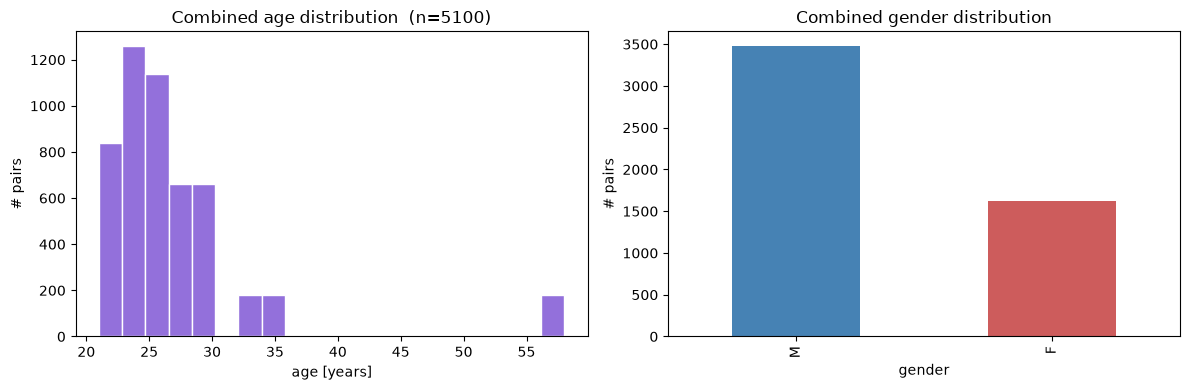

|FV age - PPG age| counts : {0: 1516, 1: 3584}
distinct identities used  : FV 70 | PPG 30


In [8]:
for col in ('fv_uid', 'ppg_subj'):
    spans = combined.groupby(col)['split'].nunique()
    leaked = spans[spans > 1]
    print(f'{col:9s}: {len(leaked)} subjects in >1 split ->', 'OK' if leaked.empty else 'LEAK!')

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.hist(combined['age'], bins=20, color='mediumpurple', edgecolor='white')
ax1.set_title(f'Combined age distribution  (n={len(combined)})')
ax1.set_xlabel('age [years]'); ax1.set_ylabel('# pairs')
combined['gender'].value_counts().plot.bar(ax=ax2, color=['steelblue', 'indianred'])
ax2.set_title('Combined gender distribution')
ax2.set_xlabel('gender'); ax2.set_ylabel('# pairs')
plt.tight_layout(); plt.show()

print('|FV age - PPG age| counts :',
      combined['age'].sub(combined['ppg_age']).abs().value_counts().sort_index().to_dict())
print('distinct identities used  : FV', combined.fv_uid.nunique(), '| PPG', combined.ppg_subj.nunique())

# **One fused sample, end to end**
Finally we materialize one combined row into the two raw inputs Model C will consume: the exact
**FingerVein ROI image** (`fv_img`) and the **PPG waveform** for `ppg_uid`, sharing one `age`
label. The loaders are the same as in notebooks 01 and 02.

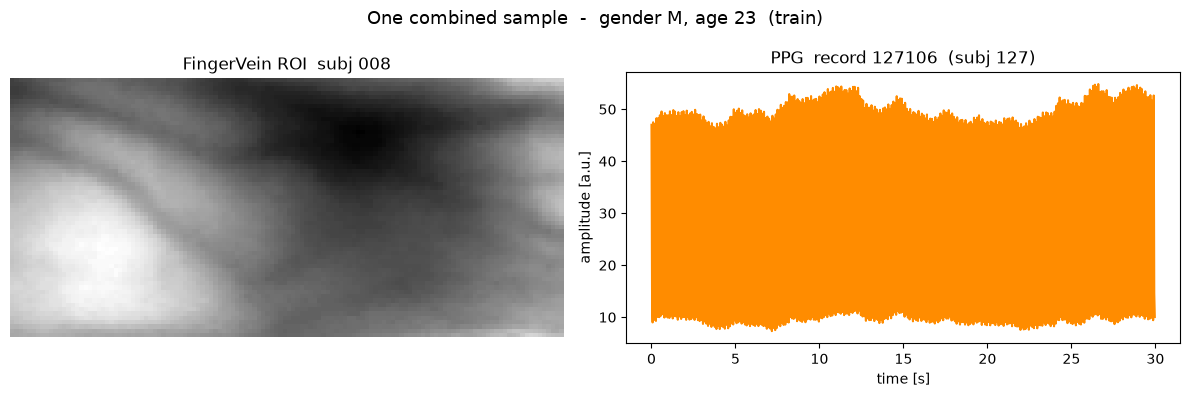

In [9]:
def load_fv_image(zip_path, img_name):
    with zipfile.ZipFile(zip_path) as z:
        return np.array(Image.open(io.BytesIO(z.read(img_name))))


def read_ppg(zip_path, record_id):
    with zipfile.ZipFile(zip_path) as z:
        base = next(n[:-4] for n in z.namelist()
                    if n.endswith(f'{record_id}/{record_id}_PPG.hea'))
        with tempfile.TemporaryDirectory() as td:
            stem = os.path.basename(base)
            for ext in ('.hea', '.dat'):
                with open(os.path.join(td, stem + ext), 'wb') as fh:
                    fh.write(z.read(base + ext))
            rec = wfdb.rdrecord(os.path.join(td, stem))
    return rec.p_signal.flatten(), rec.fs


row = combined.iloc[0]
img = load_fv_image(FV_ZIP, row['fv_img'])
sig, fs = read_ppg(PPG_ZIP, row['ppg_uid'])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.imshow(img, cmap='gray'); ax1.set_title(f"FingerVein ROI  subj {row['fv_uid']}"); ax1.axis('off')
ax2.plot(np.arange(len(sig)) / fs, sig, color='darkorange')
ax2.set_title(f"PPG  record {row['ppg_uid']}  (subj {row['ppg_subj']})")
ax2.set_xlabel('time [s]'); ax2.set_ylabel('amplitude [a.u.]')
fig.suptitle(f"One combined sample  -  gender {row['gender']}, age {row['age']}  ({row['split']})", fontsize=13)
plt.tight_layout(); plt.show()

# **Reflection: size, strategy, and limits**

**In plain words: what we did to fuse the data.**
The two datasets are *different groups of people*: the finger-vein images come from one set of
volunteers, and the PPG (heart-pulse) signals come from another. **Nobody is in both.** So we
cannot simply look up "the same person's vein image and pulse", that data does not exist.

The only thing the two groups have in common is basic demographics: a person's **sex** and
**age**. So we fuse by *matchmaking on those two facts*. Think of it like pairing dance partners
by age and sex:

1. Take a finger-vein image of, say, a **27-year-old man**.
2. Find a PPG signal from a (different) **27-year-old man** and put them together.
3. That pair becomes **one combined training example**: an image **+** a pulse signal **+** one
   shared answer (age = 27). The fused model will learn to look at both and guess the age.

We allow a small wiggle on age (`age_tol = 1`, so 26–28 counts as "same age") because exact-age
matches are rare. And because each person gave **many** images and **many** pulse recordings, we
make **many** pairs from the same people, that is the "many-to-many" part. This is how ~100
possible matches became **5100 real training examples**: we reused real data, we did **not**
invent any.

One safety rule we followed: we first divided the *people* into train / validation / test groups,
**and only then** did the matchmaking *inside* each group. That way the model never practises on a
person and then gets secretly tested on that same person, which would make it look better than it
really is.

**What we found.** The combined dataset is *sample-rich but identity-poor*: ~6000 FV images and
3888 PPG segments, but only **100 FV + 50 PPG** distinct people, concentrated in the 20s–30s and
(for FV) mostly male. Many-to-many pairing turns the abundant samples into thousands of **real**
training pairs, but it cannot add new identities.

**Strategy for the modeling notebooks.**
- *Overfitting control (committed, in-syllabus):* **Dropout + BatchNormalization + EarlyStopping**
  (as in *DL_02*), on top of the strict per-subject split.
- *Deferred (not used yet):* **data augmentation** and **transfer learning**. Both are sanctioned
  by the proposal but absent from the labs, so we only revisit them, behind a research
  checkpoint, if plain regularization proves insufficient.

**Limits to state in the exam.** Few identities ⇒ small, possibly non-representative val/test;
report combined results as **exploratory**, and read MAE / RMSE / r / R² together with
error-by-age and Bland–Altman, never in isolation.